In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import pyfftw
import cupy as cp
from PIL import Image
from numba import jit, prange

#シミュレーションおよび係数生成の時はFalse,IQファイルから画像を作成するときはTrueにする
DataFromFileMode=False
#精度を悪くする　シミュレーションの時のみ有効
BadAccuracy=False

#ポイントターゲットの時
CAL_IQ_Reverse=False #ファイル読み込み時のみ動作
OBS_IQ_Reverse=True #ファイル読み込み時のみ動作
CalIQFileName="TargetCase1_cal_20241101_124910.npy"
ObsIQFileName="TargetCase1_one_point_obs_20241101_123928.npy"
adj_pos=3500 #位置合わせ

#3ポイントターゲットの時
# CAL_IQ_Reverse= True #ファイル読み込み時のみ動作
# OBS_IQ_Reverse=True #ファイル読み込み時のみ動作
# CalIQFileName="TargetCase1_three_point_cal_20241101_152050.npy"
# ObsIQFileName="TargetCase1_three_point_obs_20241101_150347.npy"
# adj_pos=3000 #位置合わせ

#ハートマーク
# CAL_IQ_Reverse= True #ファイル読み込み時のみ動作
# OBS_IQ_Reverse=True #ファイル読み込み時のみ動作
# CalIQFileName="TargetCase1_heart_point_modify_coeff_cal_20241101_184553.npy"
# ObsIQFileName="TargetCase1_heart_point_modify_coeff_obs_20241101_184302.npy"
# adj_pos=3000 #位置合わせ


In [2]:
#npのFFTを置き換える、こちらのほうが2倍くらい早い
def my_fft(data,axis=0):
    n_threads=4
    # pyFFTWの設定
    pyfftw.interfaces.cache.enable()
    # FFTのビルダーを作成（axisを指定）
    fft_object = pyfftw.builders.fft(data, axis=axis,threads=n_threads)
    # FFTの計算
    return fft_object()

def my_ifft(data,axis=0):
    n_threads=4
    # pyFFTWの設定
    pyfftw.interfaces.cache.enable()
    # FFTのビルダーを作成（axisを指定）
    fft_object = pyfftw.builders.ifft(data, axis=axis,threads=n_threads)
    # FFTの計算
    return fft_object()


In [3]:
def peak_find(input,interval=10,num=3):
    idx = []
    data = np.abs(input)
    
    for i in range(num):
        idx_i=list(zip(*np.where(data==np.max(data))))
        idx.append(idx_i[0])
        data[idx_i[0][0]-interval//2:idx_i[0][0]+interval//2,idx_i[0][1]-interval//2:idx_i[0][1]+interval//2]=0

    return idx

# plot the data in dB scale
def image_plot_dB(data):
    plot_size_az = 20000
    plot_size_rg = 20000
    if len(data) > plot_size_az:
        az_l = len(data) // 2 - plot_size_az // 2
        az_u = len(data) // 2 + plot_size_az // 2
    else:
        az_l = 0
        az_u = len(data)
    if len(data[0]) > plot_size_rg:
        rg_l = len(data[0]) // 2 - plot_size_rg // 2
        rg_u = len(data[0]) // 2 + plot_size_rg // 2
    else:
        rg_l = 0
        rg_u = len(data[0])
    data_gpu=cp.array(data)
    plot_data = cp.abs(data_gpu[az_l:az_u, rg_l:rg_u])
    norm_factor = cp.max(plot_data)
    plot_data = plot_data / norm_factor
    threshould_dB = 60
    plot_data = cp.ceil(plot_data * 10 ** (threshould_dB / 20)) / 10 ** (
        threshould_dB / 20
    )
    # 0を非常に小さな値に置き換える
    safe_plot_data = cp.where(plot_data == 0, 1e-3, plot_data)
    plt.imshow(cp.asnumpy(20 * cp.log10(safe_plot_data)), cmap="plasma")#magma")#plasma")#viridis")#"gray")
    plt.colorbar()
    plt.show()
    del data_gpu,plot_data
    return

In [4]:
# constants
c = 299792456
# radar parameters set for case1
chirp_bw = 300e6 #75e6
fc = 9.65e9
wl = c/fc
fs = 375e6 #100e6
prf = 5000 #4000
pri = 1/prf
duty = 0.25 #3e-6*prf #0.25
chirp_len = pri*duty
chirp_rate = chirp_bw/chirp_len
chirp_mode = "down" # up, down, ud

In [5]:
# platform parameters
l_a = 4.9
w_a = 0.7
theta_l = 30 * np.pi/180
height = 550e3
r_sc = 690e3
# r0 = height/np.cos(theta_l)
veff = 7410
squint = 0.0/180*np.pi
doppler_centroid = 2*veff*np.sin(squint)/wl
# antenna pattern
theta_l_a = 0.886*wl/l_a
theta_w_a = 0.886*wl/w_a

In [6]:
# transmitted chirp pulse
time_duration = chirp_len*fs
t = np.arange(-time_duration/2,time_duration/2,1)/fs
phase = np.pi*chirp_rate*t**2
#CALデータを計算かファイルからかを選択
if(not(DataFromFileMode)):
    chirp_replica_u = np.exp(1j*phase) # up chirp
    chirp_replica_d = np.exp(-1j*phase) # down chirp
else:
    #########################################################################################
    # nbpyファイルを読み込む
    cal_data = np.load(CalIQFileName)
    #chirp_replica_d=cal_data[1][100:40+9222]/20 
    chirp_replica_d=cal_data[5] #特に加工しなくても影響なさそう
    # # 実数部と虚数部を入れ替えた新しい複素数配列を作成
    if(CAL_IQ_Reverse):
        chirp_replica_d = chirp_replica_d.imag + 1j * chirp_replica_d.real#入れ替えるといいときがある？
    chirp_replica_u = chirp_replica_d #エラーが出るので同じものを入れておく
    plt.plot(np.real(chirp_replica_d))
    plt.plot(np.imag(chirp_replica_d))
    #########################################################################################


In [7]:
# simlation swath
range_swath = 10e3
azimuth_swath = 10e3

# range time (fast time)
time_duration = (range_swath**2+azimuth_swath**2)**0.5/c
nsamples = np.ceil(time_duration*fs).astype(int) + len(chirp_replica_u)
fast_time = np.arange(0,nsamples,1)/fs + 2*r_sc/c
rg_array = c*fast_time+r_sc

# azimuth time
time_duration = azimuth_swath/veff
npulses = np.ceil(time_duration*prf).astype(int)
slow_time = np.arange(-npulses//2,npulses//2,1)/prf
az_array = veff*slow_time+r_sc*np.tan(squint)


In [8]:
#ターゲットの生成
# # 中心点の座標
center_x = r_sc + range_swath / 2
center_y = 0

def make_point_target():
    # point target
    points = [(r_sc+range_swath/2,0)]
    # points = [(r_sc+range_swath/100,0)]#for test
    # points = [(r_sc+range_swath/2-100,-100),(r_sc+range_swath/2+100,-100),(r_sc+range_swath/2,100)]#for test 三角
    return points
# 
def make_image_target(image_path):
    image = Image.open(image_path)
    # グレースケールに変換し、2値化する
    image = image.convert('L')
    threshold = 128
    binary_image = image.point(lambda p: p > threshold and 255)
    # NumPy配列に変換
    binary_array = np.array(binary_image)
    # 黒のピクセル（0）の座標を取得
    black_pixels = np.where(binary_array == 0)
    org_points = list(zip(black_pixels[1], black_pixels[0]))  
    # scaled_org_points = [(x * 5, y * 5) for x, y in org_points]
    scaled_org_points = [(x * 1, y * 2) for x, y in org_points]
    # 中心を基準にオフセット
    points = [(x + center_x, y + center_y) for x, y in scaled_org_points]
    return points

#ここでポイントか画像かを選択
# points=make_point_target()
# points=make_image_target('./small.png') #  './ya.png','./small.png','./syns3.png'
# points=make_image_target('./img/small.png') #heart mark
points=make_image_target('./img/syns3.png') #syns mark
# points=make_image_target('./strix_small.png') #syns mark

# 座標を表示
# print("points:", points)
print("points len:", len(points))


points len: 4634


In [9]:
import time
# from numba import cuda
# ターゲットシミュレータのためのフィルタ係数生成
if chirp_mode == "up" or chirp_mode == "ud":
    ss = 1
else:
    ss = -1
fir_coefficients = np.zeros((len(slow_time),len(fast_time)),dtype=np.complex64)
points = np.array(points)

#numbaで高速化を図る
# @jit(nopython=True, parallel=True)
# def compute_phase_shift(fast_time,freqs,az_array,points,squint,theta_l_a,wl,c):
#     phase_shift1=np.zeros(len(freqs),dtype=np.complex64)
#     az = az_array
#     # start_time = time.time()#1ポイント辺り1msとなる
#     for j in range(len(points)):
#         r = np.sqrt(points[j,0]**2+(points[j,1]-az)**2) 
#         angle_to_target = np.arctan((az-points[j,1])/points[j,0])
#         s_az = np.sinc((angle_to_target-squint)/theta_l_a)**2
#         delay_fft=-(fast_time-2*(r)/c)
#         phase_data=-2j * np.pi *(((freqs * delay_fft) % 1)+((2 * r / wl) % 1))
#         # ベクトル化演算を使用して計算
#         phase_shift1 += s_az * np.exp(phase_data)
#     return phase_shift1

#cupy版 結局numba(jit)よりcupy（GPU)のほうが速度がずっと速かった。
def compute_phase_shift(fast_time, freqs, az_array, points, squint, theta_l_a, wl, c):
    # 入力をCuPy配列に変換
    fast_time_gpu = cp.asarray(fast_time)
    points_gpu = cp.asarray(points)
    phase_shift_gpu = cp.zeros(len(freqs), dtype=cp.complex64)
    az_gpu = cp.asarray(az_array)
    # pointの数が多いとメモリが足りなくなるのでチャンクに分割して計算
    chunk_size=2000 #2000くらいにしておけばあまり変化ない　syns3.pngで6m5s程度
    num_points = len(points_gpu)
    for start in range(0, num_points, chunk_size):
        end = min(start + chunk_size, num_points)
        points_chunk = points_gpu[start:end]

        # すべてのポイントについてベクトル化された計算
        r = cp.sqrt(points_chunk[:, 0]**2 + (points_chunk[:, 1] - az_gpu)**2)
        angle_to_target = cp.arctan2(az_gpu - points_chunk[:, 1], points_chunk[:, 0])
        s_az = cp.sinc((angle_to_target - squint) / theta_l_a)**2
        delay_fft = -(fast_time_gpu - 2 * r / c)

        # phase_dataの計算を一括で行う
        phase_data = -2j * cp.pi * (cp.mod(freqs[:, None] * delay_fft, 1) + cp.mod(2 * r / wl, 1))

        # 各周波数について累積和を計算
        phase_shift_gpu += cp.sum(s_az * cp.exp(phase_data), axis=1)

    return phase_shift_gpu

# 周波数領域での係数生成　orignal methodは古いファイルを参照すること
freqs = cp.fft.fftfreq(len(fast_time), 1/fs)
for i in range(len(slow_time)):
    print("Generate fir_coefficients :"+str(i), end='\r')
    phase_shifts=compute_phase_shift(fast_time[0],freqs,az_array[i],points,squint,theta_l_a,wl,c)
    fir_coefficients[i,:]=cp.fft.fftshift(cp.fft.ifft(phase_shifts)).get() #このFFT処理はGPU処理が断然早い

#いくつかポイントメモ
##ベクトル化するとポイント数が増えたときにメモリサイズが大きくなり、処理できなくなる
##ポイント数のループを外側にしたりもしたが、ややこしくなる一方　jitでの並列化で不明のエラーが出るようになる
##GPU処理のほうが早いが、並列化した場合はCPU処理(numpy)のほうが早いかも=>あんまり速度に影響なさそう
##ベクトル化演算は早くてよい
        # ベクトル化演算を使用して計算
        # phase_shift1 += s_az * np.exp(phase_data)
        
#fir係数は事前にわかっているので、先にGPUメモリに入れておく
fir_coefficients_gpu=cp.asarray(fir_coefficients)


In [10]:
import scipy.io
#自作版　周波数領域を使ったConvolve関数##############################
def MyConvolve(a,b):
    N = len(a)
    # 畳み込みのフル長は2N-1なので、FFTサイズを次の2のべき乗に設定
    fft_size = 2**int(cp.ceil(np.log2(2*N - 1)))

    # FFTの計算
    A_fft = cp.fft.fft(a, fft_size)
    B_fft = cp.fft.fft(b, fft_size)

    # 周波数領域での積算
    C_fft = A_fft * B_fft

    # IFFTを用いて時系列領域に戻す
    c_full = cp.fft.ifft(C_fft)[:2*N-1]

    # 'same'モードに対応する部分を抽出（中央のN点）
    start = (2*N - 1 - N) // 2
    end = start + N
    ans = c_full[start:end].astype(cp.complex64)
    return ans
#########################################

iq_data = np.zeros((len(slow_time),len(fast_time)),dtype=np.complex64)

#CALデータを計算かファイルからかを選択
if(not(DataFromFileMode)):
    #ここが実際のリアルタイム処理が必要な場所###########################
    chirp_replica_d_gpu = cp.asarray(chirp_replica_d)
    chirp_replica_d_extended = cp.concatenate([chirp_replica_d_gpu,cp.zeros(8846-1)])
    iq_data_gpu = cp.zeros((len(slow_time),len(fast_time)),dtype=cp.complex64)

    if(BadAccuracy):
        #わざと精度を落としてみる
        chirp_replica_d_extended=chirp_replica_d_extended*16
        chirp_real_f16 = chirp_replica_d_extended.real.astype(cp.int16)
        chirp_imag_f16 = chirp_replica_d_extended.imag.astype(cp.int16)
        chirp_replica_d_extended=chirp_real_f16 + 1j * chirp_imag_f16
        fir_coefficients_gpu=fir_coefficients_gpu*16
        fir_coefficients_gpu_real_f16 = fir_coefficients_gpu.real.astype(cp.int16)
        fir_coefficients_gpu_imag_f16 = fir_coefficients_gpu.imag.astype(cp.int16)
        fir_coefficients_gpu=fir_coefficients_gpu_real_f16 + 1j * fir_coefficients_gpu_imag_f16
        del chirp_real_f16,chirp_imag_f16,fir_coefficients_gpu_real_f16,fir_coefficients_gpu_imag_f16
    for i in range(int(len(slow_time))):
        if  i % 10 == 0:
            print("TargetSim PRI:"+str(i), end='\r')
        result_gpu = cp.convolve(chirp_replica_d_extended, fir_coefficients_gpu[i,:], mode='same')
        # result_gpu = MyConvolve(chirp_replica_d_extended, fir_coefficients_gpu[i,:])
        iq_data_gpu[i] = result_gpu[:]
    iq_data=cp.asnumpy(iq_data_gpu)
    print("iq_data:",result_gpu.shape)
    if(BadAccuracy):
        iq_data = iq_data/32/16
        tmp_real = iq_data.real.astype(cp.int16)
        tmp_imag = iq_data.imag.astype(cp.int16)
        iq_data=tmp_real + 1j * tmp_imag
        del tmp_real,tmp_imag
    del iq_data_gpu
    #ここまで###################################################################

    #matlab用にファイルに保存###########################################################
    print("chirp_replica_d:",chirp_replica_d.shape)
    print("chirp_replica_d_extended:",chirp_replica_d_extended.shape)
    print("fir_coefficients_gpu:",fir_coefficients_gpu.shape)
    print("iq_data:",iq_data.shape)
    scipy.io.savemat('conv_cal_data.mat', {
        'chirp_replica_d': cp.asnumpy(chirp_replica_d),
        'chirp_replica_d_extended': cp.asnumpy(chirp_replica_d_extended),
        'fir_coefficients_gpu': cp.asnumpy(fir_coefficients_gpu),
        'conv_result_iq_data': iq_data
    })
else:
    #逆にFPGAでの取得データを取り込むときはこちら#################################
    #nbpyファイルを読み込む
    # iq_data = np.load(ObsIQFileName)
    iq_data = np.load(ObsIQFileName)
    print(iq_data.dtype)
    #シミュレーションと同じ位置になるように先頭に0を追加してみる
    #位置調整によりフォーカスも変わるので重要
    iq_data = np.pad(iq_data, pad_width=((0, 0), (adj_pos, 0)), mode='constant', constant_values=(0+0j))
    if(OBS_IQ_Reverse):
        iq_data = iq_data.imag + 1j * iq_data.real
    #データ数をシミュレーションと同じにする
    iq_data = iq_data[1:len(slow_time),1:18000]
#########################################################################################

iq_data: (36440,)0
chirp_replica_d: (18750,)
chirp_replica_d_extended: (27595,)
fir_coefficients_gpu: (6748, 36440)
iq_data: (6748, 36440)


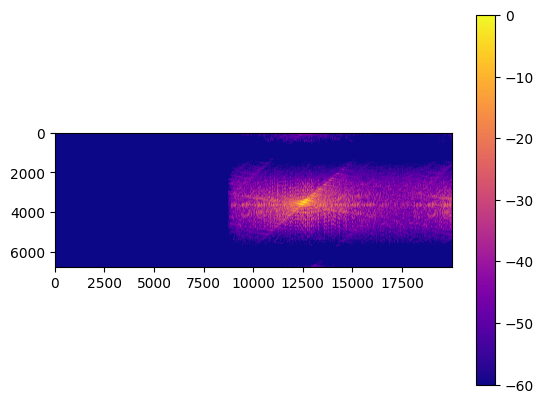

(0.001371313-0.0027070513j)


In [11]:
image_plot_dB(iq_data)
print(iq_data[3500,10000])

In [12]:
# plt.plot(iq_data[3500])

In [13]:
# preparation of range reference function
t_chirp_u = np.zeros(len(iq_data[0]),dtype=np.complex64)
t_chirp_d = np.zeros(len(iq_data[0]),dtype=np.complex64)
chirp_l = len(chirp_replica_u)
t_chirp_u[:len(chirp_replica_u)] = chirp_replica_u
t_chirp_d[:len(chirp_replica_d)] = chirp_replica_d

# convert to frequency domain
t_chirp_u_f = my_fft(t_chirp_u)
t_chirp_d_f = my_fft(t_chirp_d)


In [14]:
# range compression
# レンジ方向に周波数ドメインに変換し、リファレンス信号との相関を取る。その後、周波数ドメインから時間ドメインに戻す。
# iq_data_f = np.fft.fft(iq_data,axis=1)
iq_data_f = my_fft(iq_data,axis=1)
iq_rg_cmp = np.zeros_like(iq_data)
for i in range(iq_data.shape[0]):
    if chirp_mode == "up" or (chirp_mode =="ud" and i%2==1):
        # iq_rg_cmp[i,:] = np.fft.ifft(iq_data_f[i,:]*np.conj(t_chirp_u_f))
        iq_rg_cmp[i,:] = my_ifft(iq_data_f[i,:]*np.conj(t_chirp_u_f))

    else:
        # iq_rg_cmp[i,:] = np.fft.ifft(iq_data_f[i,:]*np.conj(t_chirp_d_f))
        iq_rg_cmp[i,:] = my_ifft(iq_data_f[i,:]*np.conj(t_chirp_d_f))        

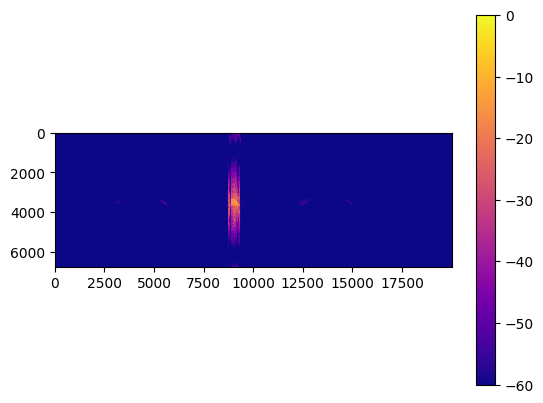

In [15]:
image_plot_dB(iq_rg_cmp)

In [16]:
# azimuth fft (rd: range-doppler domain, azimuth frequency domain)
iq_data_rd = np.fft.fftshift(my_fft(iq_rg_cmp,axis=0),axes=0)


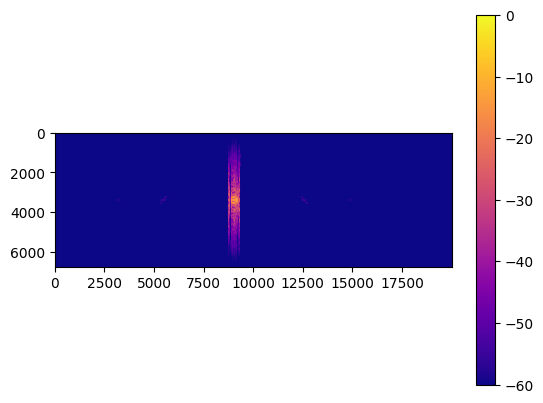

In [17]:
image_plot_dB(iq_data_rd)

In [18]:
# RCMC (range cell migration correction)
data_len = iq_data_rd.shape[0]
sample_points = np.arange(-(data_len) // 2, data_len // 2)
freq = sample_points * (prf / data_len) + doppler_centroid
freq = np.roll(
    freq, np.round(doppler_centroid / (prf / data_len)).astype(int)
)
rcm = np.zeros(iq_data_rd.shape, np.float64)
d_rg = c/2/fs
for i in range(iq_data_rd.shape[1]):
    rcm[:, i] = (1 / np.sqrt(1 - (wl * freq / (2 * veff)) ** 2) - 1) * (r_sc + d_rg * i)

R = r_sc + np.arange(0, iq_data_rd.shape[1]) * d_rg


R_new = np.tile(R, (rcm.shape[0], 1)) + rcm

iq_data_rcmc = np.zeros_like(iq_data_rd)

# for i in range(iq_data_rd.shape[0]):
#     f = interpolate.interp1d(R, iq_data_rd[i], kind="cubic", fill_value="extrapolate")
#     iq_data_rcmc[i] = f(R_new[i])

#下記の並列化で1.5倍の速さになった
from concurrent.futures import ThreadPoolExecutor
# 各行に対して補間を行う関数
def interpolate_row(i):
    f = interpolate.interp1d(R, iq_data_rd[i], kind="cubic", fill_value="extrapolate")
    return f(R_new[i])
# 並列処理の実行
with ThreadPoolExecutor() as executor:
    results = list(executor.map(interpolate_row, range(iq_data_rd.shape[0])))
# 結果を配列に格納
for i, result in enumerate(results):
    iq_data_rcmc[i] = result

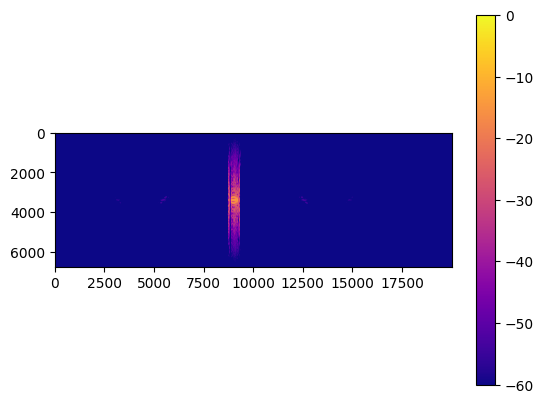

In [19]:
image_plot_dB(iq_data_rcmc)

In [20]:
# azimuth chirp signal generation
def azimuth_chirp(doppler_centroid, tau, fm_rate):
    dt = 1 / prf
    n_points = np.floor(tau * prf).astype(int)
    t = np.arange(-n_points // 2, n_points // 2) * dt
    phase = 2 * np.pi * doppler_centroid * t + np.pi * fm_rate * t**2
    chirp = np.exp(1j * phase)
    return chirp

# azimuth reference function generation
def azimuth_reference(ri, datalen):
    # squint range
    ri = ri / np.sqrt(1 - (wl * doppler_centroid) / (2 * veff) ** 2)
    # azimuth fm rate
    fm_rate = -(2 * veff**2 / wl) / ri
    # azimuth beam width
    az_beamwidth = ri * (wl / l_a) * 1.2
    # azimuth pulse length
    tau_az = az_beamwidth / veff

    # reference chirp signal
    az_ref = azimuth_chirp(doppler_centroid, tau_az, fm_rate)
    az_ref_len = len(az_ref)
    az_ref_padded = np.zeros(datalen, np.complex64)
    az_ref_padded[:az_ref_len] = az_ref
    # az_ref = np.roll(az_ref_padded, - az_ref_len//2+len(az_ref_padded)//2)
    # az_ref = np.roll(az_ref_padded, len(az_ref_padded)//2)
    shift = az_ref_len//2 + int(-(2*(doppler_centroid)/fm_rate)*prf)//2
    az_ref = np.roll(az_ref_padded, - shift)

    return az_ref

# azimuth compression
def azimuth_compression(data):
    datalen = data.shape[0]
    for i in range(len(data[0])):
        ri = r_sc + c / (2 * fs) * i
        az_ref = azimuth_reference(ri, datalen)
        az_ref = np.conj(np.fft.fftshift(my_fft(az_ref))).astype(np.complex64)
        data[:, i] = data[:, i] * az_ref
    return data

In [21]:
# azimuth compression
iq_az_cmp = azimuth_compression(iq_data_rcmc)

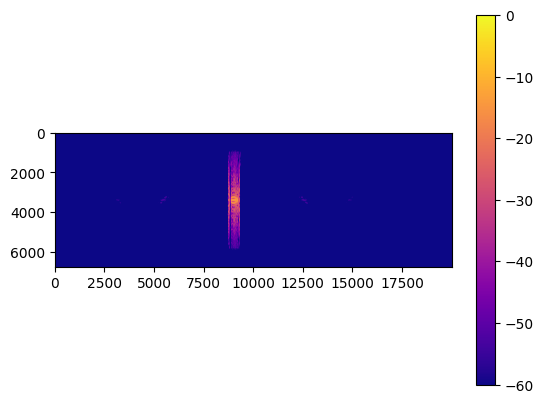

In [22]:
image_plot_dB(iq_az_cmp)

In [23]:
# azimuth ifft
slc = my_ifft(np.fft.fftshift(iq_az_cmp,axes=0),axis=0)


[(3382, 17302)]


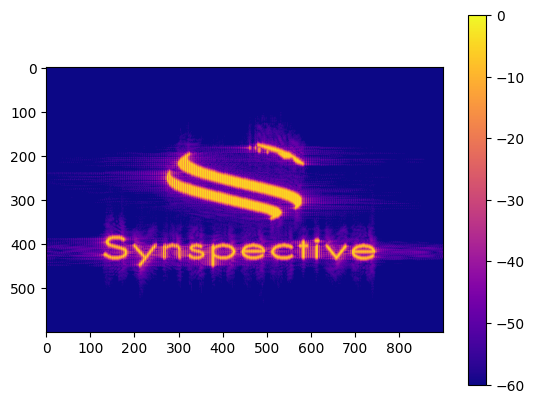

In [40]:
peak_idx = peak_find(slc, interval=10, num=1)
print(peak_idx)
# plot_len = 1000
# image_plot_dB(slc[peak_idx[0][0]-plot_len//2:peak_idx[0][0]+plot_len//2,peak_idx[0][1]-plot_len//2:peak_idx[0][1]+plot_len//2])
image_plot_dB(slc[3200:3800,16800:17700])#syns mark
# image_plot_dB(slc[3000:7500,4000:11000])#strix
# image_plot_dB(slc[3200:4000,5900:6900])#syns3.png

In [25]:
# image_plot_dB(slc[1000:6500,3500:9500])#syns3.png

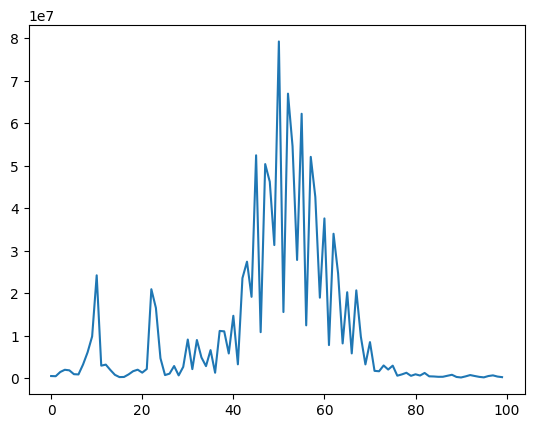

In [26]:
# range profile
plot_len = 100
plt.plot(np.abs(slc[peak_idx[0][0],peak_idx[0][1]-plot_len//2:peak_idx[0][1]+plot_len//2]))

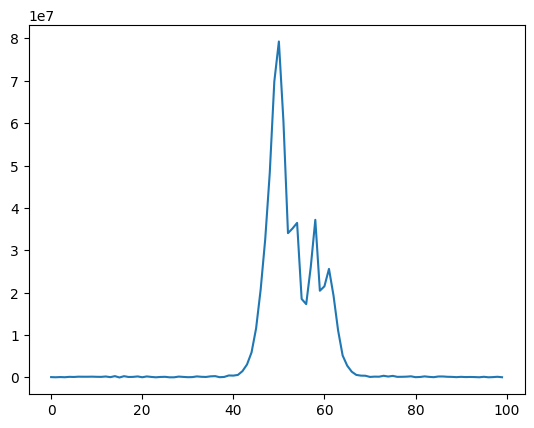

In [27]:
# azimuth profile
plot_len = 100
plt.plot(np.abs(slc[peak_idx[0][0]-plot_len//2:peak_idx[0][0]+plot_len//2,peak_idx[0][1]]))

In [28]:
from scipy.signal import peak_widths

def resolution_estimation(data, interp_ratio=10):
    data = np.abs(data)
    idx = np.argmax(data)

    range_cut = data[idx // data.shape[1]]
    azimuth_cut = data[:, idx % data.shape[1]]

    range_cut = np.abs(fft_interp(range_cut, interp_ratio)) ** 2
    peak_idx_rg = [np.argmax(range_cut)]
    width_rg = peak_widths(range_cut, peak_idx_rg, rel_height=0.5)

    azimuth_cut = np.abs(fft_interp(azimuth_cut, interp_ratio)) ** 2
    peak_idx_az = [np.argmax(azimuth_cut)]
    width_az = peak_widths(azimuth_cut, peak_idx_az, rel_height=0.5)

    return width_rg[0] / interp_ratio, width_az[0] / interp_ratio

# fft interpolator
def fft_interp(sig, interp_ratio):
    sig_f = np.fft.fftshift(my_fft(sig))
    tmp = np.zeros(len(sig) * interp_ratio, dtype=np.complex64)
    tmp[0 : len(sig_f)] = sig_f
    tmp = np.roll(tmp, len(tmp) // 2 - len(sig_f) // 2)
    return np.fft.ifft(np.fft.fftshift(tmp)).astype(np.complex64)


In [29]:
d_rg = c/2/fs
d_az = veff/prf
res_rg, res_az = resolution_estimation(slc)
print("range resolution: ", res_rg*d_rg)
print("azimuth resolution: ", res_az*d_az)

range resolution:  [0.4191433]
azimuth resolution:  [4.06546]


In [30]:

print("slow time:"+str(len(slow_time)))
print("fast time:"+str(len(fast_time)))


slow time:6748
fast time:36440
